### Multimodal Retrieval Augmented Generation (RAG) using the Vertex AI Gemini API

In [1]:
! pip3 install --upgrade --user google-genai pymupdf rich colorama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 117.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0/2 [pymupdf]  WARNING: The script pymupdf is installed in '/home/jupyter/.local/bin' which is not on PATH.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rich]1/2 [rich]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.38.0 requires rich<14,>=12.4.4, but you have rich 14.3.4 which is incompatible.


In [1]:
import IPython

app = IPython.Application.instance()
app.kernel.do_shutdown(True)

{'status': 'ok', 'restart': True}

In [1]:
PROJECT = !gcloud config get-value project
PROJECT_ID = PROJECT[0]
LOCATION = "us-central1"

In [3]:
from IPython.display import Markdown, display
from rich.markdown import Markdown as rich_Markdown
from vertexai.generative_models import (
    Content,
    GenerationConfig,
    GenerationResponse,
    GenerativeModel,
    HarmCategory,
    HarmBlockThreshold,
    Image,
    Part,
)
from vertexai.language_models import TextEmbeddingModel

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.aiplatform_v1beta1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.aiplatform_v1beta1 past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_supp

In [8]:
multimodal_model = GenerativeModel("gemini-2.5-flash")
multimodal_model_flash = GenerativeModel("gemini-2.5-flash")
text_embedding_model = TextEmbeddingModel.from_pretrained("text-embedding-005")

/home/jupyter/.local/lib/python3.10/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()
/home/jupyter/.local/lib/python3.10/site-packages/vertexai/_model_garden/_model_garden_models.py:278: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


In [9]:
# download documents and images used in this notebook
!gsutil -m rsync -r gs://github-repo/rag/intro_multimodal_rag/intro_multimodal_rag_old_version .
print("Download completed")

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Building synchronization state...
Starting synchronization...
Download completed


In [10]:
from intro_multimodal_rag_utils import get_document_metadata

In [11]:
# Specify the PDF folder with multiple PDF

# pdf_folder_path = "/content/data/" # if running in Google Colab/Colab Enterprise
pdf_folder_path = "data/"  # if running in Vertex AI Workbench.

# Specify the image description prompt. Change it
image_description_prompt = """Explain what is going on in the image.
If it's a table, extract all elements of the table.
If it's a graph, explain the findings in the graph.
Do not include any numbers that are not mentioned in the image.
"""

# Extract text and image metadata from the PDF document
text_metadata_df, image_metadata_df = get_document_metadata(
    multimodal_model,  # gemini-2.5-flash
    pdf_folder_path,
    image_save_dir="images",
    image_description_prompt=image_description_prompt,
    embedding_size=1408,
    add_sleep_after_page = True,
    sleep_time_after_page = 30, # Increase time if you are running into API quota issues
)

print("\n\n --- Completed processing. ---")



 Processing the file: --------------------------------- data/google-10k-sample-part1.pdf 


Processing page: 1
Sleeping for  30  sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = False"  
Processing page: 2
Extracting image from page: 2, saved as: images/google-10k-sample-part1.pdf_image_1_0_11.jpeg


/home/jupyter/.local/lib/python3.10/site-packages/vertexai/vision_models/_vision_models.py:154: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


Sleeping for  30  sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = False"  
Processing page: 3
Extracting image from page: 3, saved as: images/google-10k-sample-part1.pdf_image_2_0_15.jpeg
Sleeping for  30  sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = False"  
Processing page: 4
Extracting image from page: 4, saved as: images/google-10k-sample-part1.pdf_image_3_0_18.jpeg
Sleeping for  30  sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = False"  
Processing page: 5
Extracting image from page: 5, saved as: images/google-10k-sample-part1.pdf_image_4_0_21.jpeg
Sleeping for  30  sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = False"  
Processing page: 6
Sleeping for  30  sec before processing the next page to avoid quota issues. You can disable it: "add_sleep_after_page = F

In [12]:
text_metadata_df.head()

,file_name,page_num,text,text_embedding_page,chunk_number,chunk_text,text_embedding_chunk
0,google-10k-sample-part1.pdf,1,source: https://abc.xyz/assets/investor/static...,"[0.06604167073965073, 0.054615460336208344, -0...",1,source: https://abc.xyz/assets/investor/static...,"[0.05712887644767761, 0.06096643581986427, -0...."
1,google-10k-sample-part1.pdf,1,source: https://abc.xyz/assets/investor/static...,"[0.06604167073965073, 0.054615460336208344, -0...",2,"of Record\nAs of December 31, 2021, there wer...","[0.030928857624530792, 0.02287178672850132, -0..."
2,google-10k-sample-part1.pdf,2,Issuer Purchases of Equity Securities\nThe fol...,"[0.035787057131528854, 0.008179700933396816, -...",1,Issuer Purchases of Equity Securities\nThe fol...,"[0.035787057131528854, 0.008179700933396816, -..."
3,google-10k-sample-part1.pdf,3,Stock Performance Graphs\nThe graph below matc...,"[0.04338429123163223, 0.024151558056473732, -0...",1,Stock Performance Graphs\nThe graph below matc...,"[0.04338429123163223, 0.024151558056473732, -0..."
4,google-10k-sample-part1.pdf,4,The graph below matches Alphabet Inc. Class A'...,"[0.05739395692944527, 0.02924434281885624, -0....",1,The graph below matches Alphabet Inc. Class A'...,"[0.05739395692944527, 0.02924434281885624, -0...."


In [13]:
image_metadata_df.head()

,file_name,page_num,img_num,img_path,img_desc,mm_embedding_from_img_only,text_embedding_from_image_description
0,google-10k-sample-part1.pdf,2,1,images/google-10k-sample-part1.pdf_image_1_0_1...,This image displays a table detailing share re...,"[0.0232483614, -0.000801577757, 0.0152807366, ...","[0.0363016314804554, 0.016287585720419884, 0.0..."
1,google-10k-sample-part1.pdf,3,1,images/google-10k-sample-part1.pdf_image_2_0_1...,This image is a **graph**.\n\n**Explanation of...,"[0.00688705454, 0.0237270854, -0.00903039426, ...","[0.04625783860683441, 0.02082950435578823, -0...."
2,google-10k-sample-part1.pdf,4,1,images/google-10k-sample-part1.pdf_image_3_0_1...,"This image is a line graph titled ""COMPARISON ...","[0.0065865512, 0.0104530435, -0.00870084949, 0...","[0.04203047230839729, 0.025491120293736458, -0..."
3,google-10k-sample-part1.pdf,5,1,images/google-10k-sample-part1.pdf_image_4_0_2...,This image is a financial table presenting a c...,"[0.0166553948, 0.0199897066, -0.0204031914, -0...","[0.044415026903152466, 0.027521569281816483, -..."
4,google-10k-sample-part2.pdf,1,1,images/google-10k-sample-part2.pdf_image_0_0_6...,This is a table.\n\nHere are all the elements ...,"[0.0357288, 0.0324414149, 0.0125657273, -0.026...","[-0.001255473354831338, 0.04991636425256729, -..."


In [14]:
from intro_multimodal_rag_utils import (
    get_similar_text_from_query,
    print_text_to_text_citation,
    get_similar_image_from_query,
    print_text_to_image_citation,
    get_gemini_response,
    display_images,
)

In [15]:
query = "I need details for basic and diluted net income per share of Class A, Class B, and Class C share for google?"

In [16]:
# Matching user text query with "chunk_embedding" to find relevant chunks.
matching_results_text = get_similar_text_from_query(
    query,
    text_metadata_df,
    column_name="text_embedding_chunk",
    top_n=3,
    chunk_text=True,
)

# Print the matched text citations
print_text_to_text_citation(matching_results_text, print_top=False, chunk_text=True)

Citation 1: Matched text: 

score:  0.76
file_name:  google-10k-sample-part2.pdf
page_number:  4
chunk_number:  1
chunk_text:  liquidation and dividend rights are identical, the undistributed earnings are
allocated on a proportionate basis.
In the years ended December 31, 2019, 2020 and 2021, the net income per
share amounts are the same for Class A, Class B, and Class C stock because
the holders of each class are entitled to equal per share dividends or distributions
in liquidation in accordance with the Amended and Restated Certificate of
Incorporation of Alphabet Inc.
The following tables set forth the computation of basic and diluted net income per
share of Class A, Class B, and Class C stock (in millions, except share amounts
which are reflected in thousands and per share amounts):

Citation 2: Matched text: 

score:  0.7
file_name:  google-10k-sample-part2.pdf
page_number:  3
chunk_number:  1
chunk_text:  increases in content acquisition costs primarily for YouTube, data center a


 **** Result: ***** 



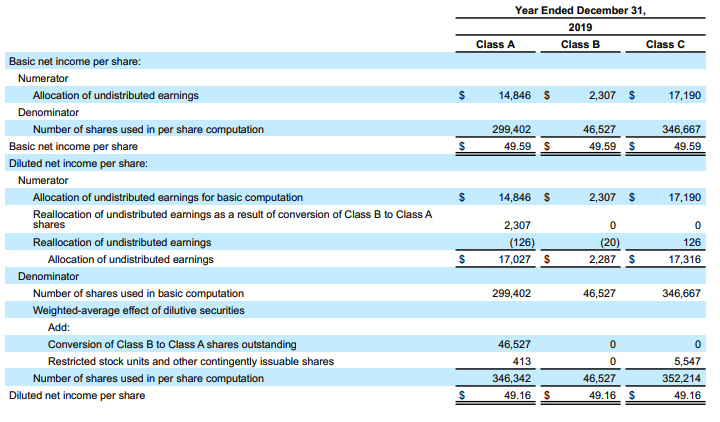

In [17]:
matching_results_image = get_similar_image_from_query(
    text_metadata_df,
    image_metadata_df,
    query=query,
    column_name="text_embedding_from_image_description",  # Use image description text embedding
    image_emb=False,  # Use text embedding instead of image embedding
    top_n=3,
    embedding_size=1408,
)

# Markdown(print_text_to_image_citation(matching_results_image, print_top=True))
print("\n **** Result: ***** \n")

# Display the top matching image
display(matching_results_image[0]["image_object"])

In [18]:
## you can check the citations to probe further.
## check the "image description:" which is a description extracted through gemini which helped search our query.
Markdown(print_text_to_image_citation(matching_results_image, print_top=True))

Citation 1: Matched image path, page number and page text: 

score:  0.7
file_name:  google-10k-sample-part2.pdf
path:  images/google-10k-sample-part2.pdf_image_3_0_19.jpeg
page number:  4
page text:  liquidation and dividend rights are identical, the undistributed earnings are
allocated on a proportionate basis.
In the years ended December 31, 2019, 2020 and 2021, the net income per
share amounts are the same for Class A, Class B, and Class C stock because
the holders of each class are entitled to equal per share dividends or distributions
in liquidation in accordance with the Amended and Restated Certificate of
Incorporation of Alphabet Inc.
The following tables set forth the computation of basic and diluted net income per
share of Class A, Class B, and Class C stock (in millions, except share amounts
which are reflected in thousands and per share amounts):

image description:  This image is a financial table detailing the calculation of basic and diluted net income per share for the

<IPython.core.display.Markdown object>

***Input image from user:***


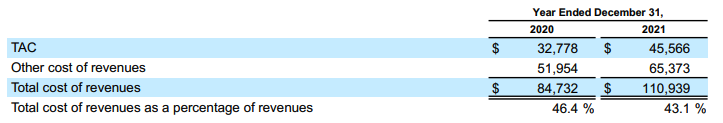

In [19]:
# You can find a similar image as per the images you have in the metadata.
# In this case, you have a table (picked from the same document source) and you would like to find similar tables in the document.
image_query_path = "tac_table_revenue.png"

# Print a message indicating the input image
print("***Input image from user:***")

# Display the input image
Image.load_from_file(image_query_path)

/home/jupyter/.local/lib/python3.10/site-packages/vertexai/vision_models/_vision_models.py:154: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()



 **** Result: ***** 



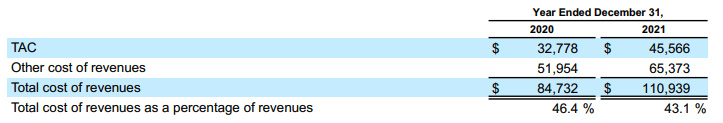

In [20]:
# Search for Similar Images Based on Input Image and Image Embedding

matching_results_image = get_similar_image_from_query(
    text_metadata_df,
    image_metadata_df,
    query=query,  # Use query text for additional filtering (optional)
    column_name="mm_embedding_from_img_only",  # Use image embedding for similarity calculation
    image_emb=True,
    image_query_path=image_query_path,  # Use input image for similarity calculation
    top_n=3,  # Retrieve top 3 matching images
    embedding_size=1408,  # Use embedding size of 1408
)

print("\n **** Result: ***** \n")

# Display the Top Matching Image
display(
    matching_results_image[0]["image_object"]
)  # Display the top matching image object (Pillow Image)

In [21]:
# Display citation details for the top matching image
print_text_to_image_citation(
    matching_results_image, print_top=True
)  # Print citation details for the top matching image

Citation 1: Matched image path, page number and page text: 

score:  0.99
file_name:  google-10k-sample-part2.pdf
path:  images/google-10k-sample-part2.pdf_image_1_0_13.jpeg
page number:  2
page text:  APAC revenue growth from 2020 to 2021 was favorably affected by foreign
currency exchange rates, primarily due to the U.S. dollar weakening relative to
the Australian dollar, partially offset by the U.S. dollar strengthening relative to
the Japanese yen.
Other Americas growth change from 2020 to 2021 was favorably affected by
changes in foreign currency exchange rates, primarily due to the U.S. dollar
weakening relative to the Canadian dollar, partially offset by the U.S. dollar
strengthening relative to the Argentine peso and the Brazilian real.
Costs and Expenses
Cost of Revenues
The following tables present cost of revenues, including TAC (in millions, except
percentages):
Cost of revenues increased $26.2 billion from 2020 to 2021. The increase was
due to an increase in other cost of 

---------------Matched Images------------------



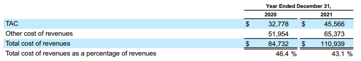

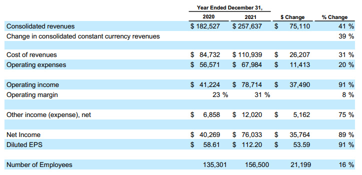

In [22]:
# Check Other Matched Images (Optional)
# You can access the other two matched images using:

print("---------------Matched Images------------------\n")
display_images(
    [
        matching_results_image[0]["img_path"],
        matching_results_image[1]["img_path"],
    ],
    resize_ratio=0.5,
)

***Input image from user:***


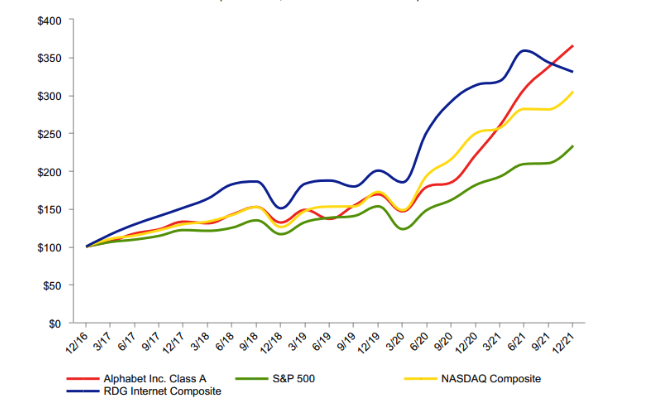

In [23]:
from IPython.display import Image as IPyImage, display

image_query_path = "class_a_share.png"

# Print a message indicating the input image
print("***Input image from user:***")

# Display the input image inline in the notebook
display(IPyImage(filename=image_query_path))

In [24]:
# Load the input image using Pillow
user_image_object = Image.load_from_file(image_query_path)

# Define the comparison query
compare_query = """Question: How has nasdaq performed with respect to Class A and Class B shares of Google?
Answer: """
instructions = """instructions: Compare two images and base your reasoning only on the images provided.
Provide detail reasoning of your conclusions.
Images: """

# Find similar images based on the input image
image_selected_based_on_source_image = get_similar_image_from_query(
    text_metadata_df,
    image_metadata_df,
    image_query_path=image_query_path,
    column_name="mm_embedding_from_img_only",
    image_emb=True,
    top_n=3,
    embedding_size=1408,
)

# Select the best matching image from the search results
selected_image_object = image_selected_based_on_source_image[0]["image_object"]

# Prepare the model input
model_input = [instructions, user_image_object, selected_image_object, compare_query]

# Generate Gemini response with streaming output
Markdown(get_gemini_response(multimodal_model_flash, model_input=model_input, stream=True))


Based on the images provided:

1.  **Information on Google Shares:** The images only provide data for "Alphabet Inc. Class A" (represented by the red line). There is no data presented for "Alphabet Inc. Class B" shares. Therefore, a comparison of NASDAQ's performance with respect to Class B shares cannot be made from these images.

2.  **NASDAQ Composite vs. Alphabet Inc. Class A:**
    *   **Initial Period (12/16 to approximately 6/20):** The NASDAQ Composite (yellow line) generally performed similarly to or slightly better than Alphabet Inc. Class A (red line). There were periods where NASDAQ was slightly above Alphabet A (e.g., 3/17, 3/18, 9/18, 3/19, 6/19, 3/20) and periods where Alphabet A was slightly above NASDAQ (e.g., 9/17, 6/18, 12/19). Both experienced a significant dip around 3/20, with NASDAQ recovering slightly faster initially.
    *   **Later Period (approximately 6/20 to 12/21):** Alphabet Inc. Class A significantly outperformed the NASDAQ Composite. Starting around 6/20, Alphabet A's growth accelerated, and it surpassed NASDAQ around 9/20. This outperformance continued, with Alphabet A reaching a peak around 6/21 significantly above NASDAQ.
    *   **End of Period (12/21):** By the end of the period shown (12/21), Alphabet Inc. Class A had a higher cumulative return than the NASDAQ Composite. Alphabet A was around $340-$350, while NASDAQ Composite was around $300-$310.

In summary, while NASDAQ Composite showed comparable or slightly better performance than Alphabet Inc. Class A for the first half of the period, Alphabet Inc. Class A demonstrated stronger growth and significantly outperformed the NASDAQ Composite in the latter half of the period, ending with a higher cumulative return. No comparison can be made for Class B shares.

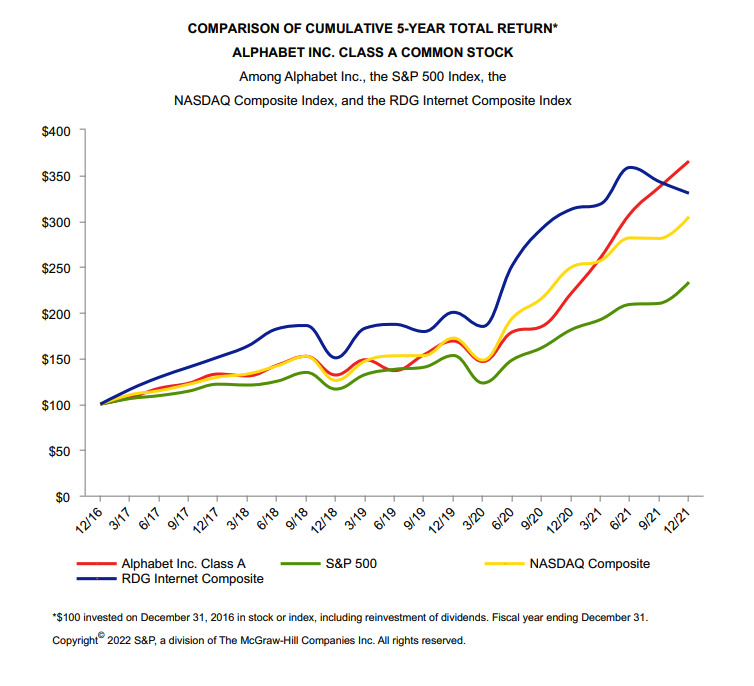

In [25]:
Image.load_from_file(image_selected_based_on_source_image[0]["img_path"])

In [26]:
# citations
print_text_to_image_citation(image_selected_based_on_source_image, print_top=True)

Citation 1: Matched image path, page number and page text: 

score:  0.74
file_name:  google-10k-sample-part1.pdf
path:  images/google-10k-sample-part1.pdf_image_2_0_15.jpeg
page number:  3
page text:  Stock Performance Graphs
The graph below matches Alphabet Inc. Class A's cumulative 5-year total
stockholder return on common stock with the cumulative total returns of the S&P
500 index, the NASDAQ Composite index, and the RDG Internet Composite
index. The graph tracks the performance of a $100 investment in our common
stock and in each index (with the reinvestment of all dividends) from December
31, 2016 to December 31, 2021. The returns shown are based on historical
results and are not intended to suggest future performance.

image description:  This image is a **graph**.

**Explanation of the findings in the graph:**

The graph presents a comparison of the cumulative 5-year total return for Alphabet Inc. Class A Common Stock against three market indices: the S&P 500 Index, the NASDAQ

In [27]:
# this time we are not passing any images, but just a simple text query.

query = """Question: How has nasdaq and s&p performed with respect to class A shares and class C shares?
Which one would be better to buy and why?
Answer: """

# query = """Question: Find the total revenues and other related financial numbers for Alphabet
# Answer: """


In [28]:
# Retrieve relevant chunks of text based on the query
matching_results_chunks_data = get_similar_text_from_query(
    query,
    text_metadata_df,
    column_name="text_embedding_chunk",
    top_n=10,
    chunk_text=True,
)

In [29]:
# Get all relevant images based on user query
matching_results_image_fromdescription_data = get_similar_image_from_query(
    text_metadata_df,
    image_metadata_df,
    query=query,
    column_name="text_embedding_from_image_description",
    image_emb=False,
    top_n=10,
    embedding_size=1408,
)

In [30]:
# combine all the selected relevant text chunks
context_text = []
for key, value in matching_results_chunks_data.items():
    context_text.append(value["chunk_text"])
final_context_text = "\n".join(context_text)

# combine all the relevant images and their description generated by Gemini
context_images = []
for key, value in matching_results_image_fromdescription_data.items():
    context_images.extend(
        ["Image: ", value["image_object"], "Caption: ", value["image_description"]]
    )

In [31]:
instructions = """The context of extraction of detail should be based on the text context given in "text_context" and Image context given in "image_context" along with its Caption: \n
Base your response on "text_context" and "image_context". Do not use any numbers or percentages that are not present in the "image_context".
Do not include any cumulative total return in the answer. Context:
"""

final_prompt = [
    query,
    instructions,
    "text_context:",
    "\n".join(context_text),
    "image_context:",
]
final_prompt.extend(context_images)

In [32]:
Markdown(get_gemini_response(multimodal_model_flash, model_input=final_prompt, stream=True))

Based on the provided context:

**How Nasdaq and S&P have performed with respect to Class A shares and Class C shares:**

The image context provides graphs comparing the performance of Alphabet Inc. Class A Common Stock against the S&P 500 Index and the NASDAQ Composite Index. These graphs show that Alphabet Inc. Class A generally performs better than the S&P 50

---------------Matched Images------------------



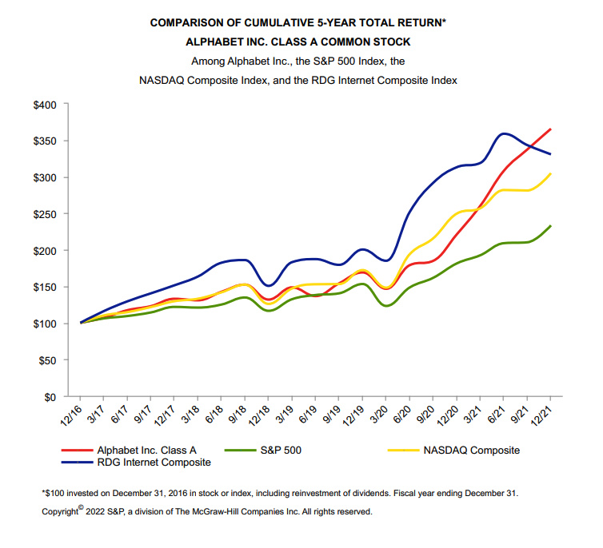

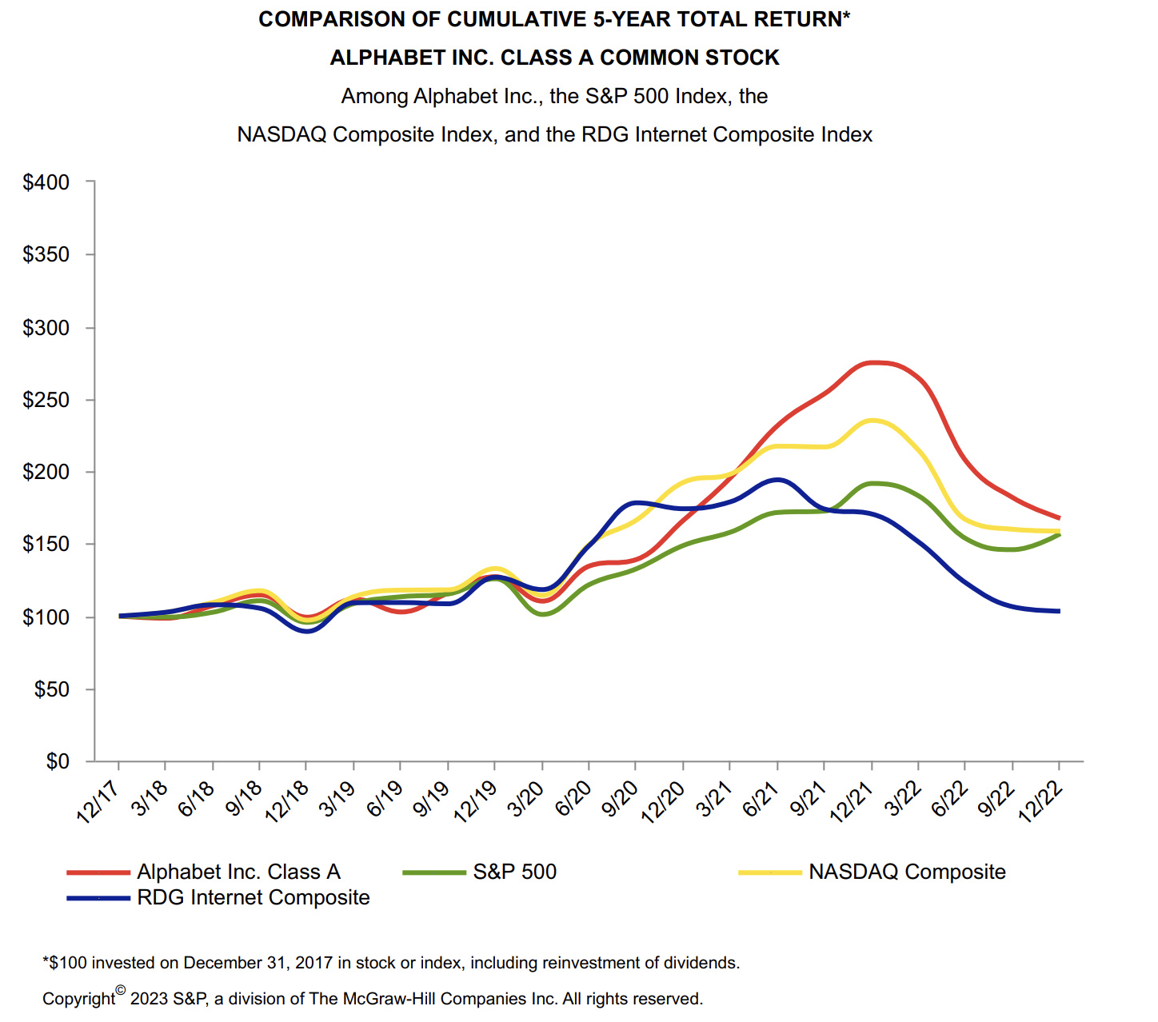

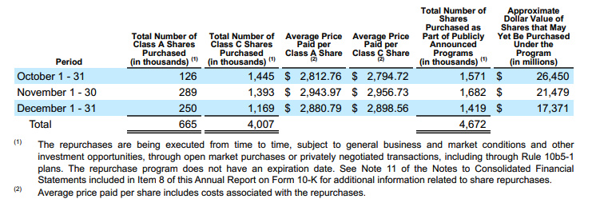

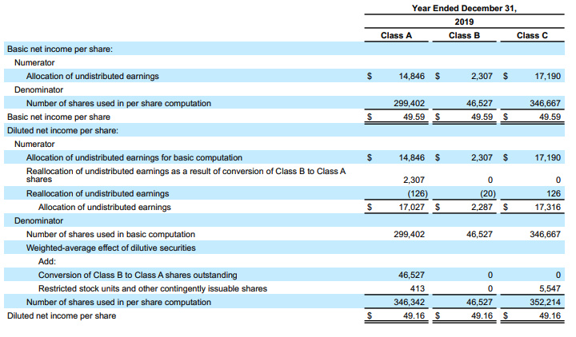

In [33]:
print("---------------Matched Images------------------\n")
display_images(
    [
        matching_results_image_fromdescription_data[0]["img_path"],
        matching_results_image_fromdescription_data[1]["img_path"],
        matching_results_image_fromdescription_data[2]["img_path"],
        matching_results_image_fromdescription_data[3]["img_path"],
    ],
    resize_ratio=0.8,
)

In [34]:
# Image citations. You can check how Gemini generated metadata helped in grounding the answer.

print_text_to_image_citation(
    matching_results_image_fromdescription_data, print_top=False
)

Citation 1: Matched image path, page number and page text: 

score:  0.59
file_name:  google-10k-sample-part1.pdf
path:  images/google-10k-sample-part1.pdf_image_2_0_15.jpeg
page number:  3
page text:  Stock Performance Graphs
The graph below matches Alphabet Inc. Class A's cumulative 5-year total
stockholder return on common stock with the cumulative total returns of the S&P
500 index, the NASDAQ Composite index, and the RDG Internet Composite
index. The graph tracks the performance of a $100 investment in our common
stock and in each index (with the reinvestment of all dividends) from December
31, 2016 to December 31, 2021. The returns shown are based on historical
results and are not intended to suggest future performance.

image description:  This image is a **graph**.

**Explanation of the findings in the graph:**

The graph presents a comparison of the cumulative 5-year total return for Alphabet Inc. Class A Common Stock against three market indices: the S&P 500 Index, the NASDAQ

In [35]:
# Text citations

print_text_to_text_citation(
    matching_results_chunks_data,
    print_top=False,
    chunk_text=True,
)

Citation 1: Matched text: 

score:  0.59
file_name:  google-10k-sample-part1.pdf
page_number:  3
chunk_number:  1
chunk_text:  Stock Performance Graphs
The graph below matches Alphabet Inc. Class A's cumulative 5-year total
stockholder return on common stock with the cumulative total returns of the S&P
500 index, the NASDAQ Composite index, and the RDG Internet Composite
index. The graph tracks the performance of a $100 investment in our common
stock and in each index (with the reinvestment of all dividends) from December
31, 2016 to December 31, 2021. The returns shown are based on historical
results and are not intended to suggest future performance.

Citation 2: Matched text: 

score:  0.57
file_name:  google-10k-sample-part1.pdf
page_number:  2
chunk_number:  1
chunk_text:  Issuer Purchases of Equity Securities
The following table presents information with respect to Alphabet's repurchases
of Class A common stock and Class C capital stock during the quarter ended
December 31, 2021:

In [ ]:
# The End